In [100]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
# import matplotlib.pyplot as plt
# from spikingjelly.activation_based.encoding import PoissonEncoder
# import random
# import torch
# from torch import nn
# from torch.nn import functional as F
# from torch import optim
# from tqdm import tqdm
# from spikingjelly.activation_based.neuron import LIFNode, ParametricLIFNode
# from data import PermutedMNIST,PermutedFASHION,RotatedMNIST
# from utils import EWC, ewc_train, normal_train, test,evaluate_val_loss,EWC1, ewc_train1, normal_train1, test1
# import spikingjelly as sj
# from spikingjelly.activation_based import encoding
# from torch.optim.lr_scheduler import CosineAnnealingLR,ReduceLROnPlateau
# from spikingjelly import visualizing
# from spikingjelly.activation_based import layer, neuron, surrogate, encoding
# import csv
# import numpy as np
# import pandas as pd

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  
# 必须在导入 torch 之前设置

import matplotlib.pyplot as plt
from spikingjelly.activation_based.encoding import PoissonEncoder
import random
import torch          # 现在导入 torch
from torch import nn
from torch.nn import functional as F
from torch import optim
from tqdm import tqdm
from spikingjelly.activation_based.neuron import LIFNode, ParametricLIFNode
from data import PermutedMNIST,PermutedFASHION,RotatedMNIST
from utils import EWC, ewc_train, normal_train, test,evaluate_val_loss,EWC1, ewc_train1, normal_train1, test1
import spikingjelly as sj
from spikingjelly.activation_based import encoding
from torch.optim.lr_scheduler import CosineAnnealingLR,ReduceLROnPlateau
from spikingjelly import visualizing
from spikingjelly.activation_based import layer, neuron, surrogate, encoding
import csv
import numpy as np
import pandas as pd

# 打印设备信息
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Number of visible devices:", torch.cuda.device_count())   # 应该输出 1
    print("Current visible device index:", torch.cuda.current_device())  # 输出 0
    print("Device name (physical GPU 1):", torch.cuda.get_device_name(0))

CUDA available: True
Number of visible devices: 2
Current visible device index: 0
Device name (physical GPU 1): NVIDIA GeForce RTX 3090


In [101]:
epochs = 10
lr = 1e-3
batch_size = 256
num_task = 10
sample_size = 256

In [102]:
class SNN(nn.Module):
    def __init__(self, tau):
        super().__init__()
        self.encoder = encoding.PoissonEncoder()  # 将编码器作为模型的一部分
        self.layer = nn.Sequential(
            layer.Linear(28 * 28, 3000, bias=False),  # 第一个隐藏层
            neuron.ParametricLIFNode(init_tau=tau, surrogate_function=surrogate.ATan()),
            # layer.Linear(512, 400, bias=False),  # 第二个隐藏层
            # neuron.LIFNode(tau=tau, surrogate_function=surrogate.ATan()),
            layer.Linear(3000, 10, bias=False),  # 输出层
            #neuron.ParametricLIFNode(init_tau=tau, surrogate_function=surrogate.ATan()),
        )
    
    def forward(self, x: torch.Tensor):
        # 编码输入图像为尖峰信号
        x = self.encoder(x)
        # 通过SNN层进行前向传播
        x = self.layer(x)
        # 确保输出形状为 (batch_size, 10)
        return x.view(-1, 10)  # 调整输出形状为 (batch_size, 10)
# class SNN(nn.Module):
#     def __init__(self, tau=2.0):
#         super().__init__()
#         self.encoder = encoding.PoissonEncoder()
        
#         # 保持与原始网络完全相同的结构
#         self.layer = nn.Sequential(
#             layer.Linear(28 * 28, 2000, bias=False),
#             nn.BatchNorm1d(2000),
#             neuron.ParametricLIFNode(init_tau=tau, surrogate_function=surrogate.ATan()),
#             layer.Linear(2000, 10, bias=False),
#         )
    
#     def forward(self, x: torch.Tensor):
#         # 保持与原始网络相同的处理流程
#         x = self.encoder(x)
#         x = self.layer(x)
#         return x.view(-1, 10)  # 输出形状保持为 (batch_size, 10)

In [103]:
class MLP(nn.Module):
    def __init__(self, hidden_size=2000):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, hidden_size)
        # self.fc2 = nn.Linear(hidden_size, hidden_size)
        # self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, 10)

    def forward(self, input):
        x = F.relu(self.fc1(input))
        # x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x)) 
        return x


In [104]:
def get_permute_mnist():
    train_loader = {}
    test_loader = {}
    idx = list(range(28 * 28))
    for i in range(num_task):
        train_loader[i] = torch.utils.data.DataLoader(PermutedMNIST(root= '/home/lipuyang/lab1/data',train=True, permute_idx=idx),
                                                      batch_size=batch_size,
                                                      num_workers=4
                                                      )
        test_loader[i] = torch.utils.data.DataLoader(PermutedMNIST(root= '/home/lipuyang/lab1/data',train=False, permute_idx=idx),
                                                     batch_size=batch_size)
        random.shuffle(idx)
    return train_loader, test_loader

def get_permute_fashion():
    train_loader = {}
    test_loader = {}
    idx = list(range(28 * 28))
    for i in range(num_task):
        train_loader[i] = torch.utils.data.DataLoader(PermutedFASHION(root= '/home/lipuyang/lab1/data',train=True, permute_idx=idx),
                                                      batch_size=batch_size,
                                                      num_workers=4
                                                      )
        test_loader[i] = torch.utils.data.DataLoader(PermutedFASHION(root= '/home/lipuyang/lab1/data',train=False, permute_idx=idx),
                                                     batch_size=batch_size)
        random.shuffle(idx)
    return train_loader, test_loader
def get_rotated_mnist(num_task=10, batch_size=256):
    train_loader = {}
    test_loader = {}
    
    # 为每个任务生成不同的旋转角度
    angles = [i * (90 / num_task) for i in range(num_task)]
    
    for i in range(num_task):
        # 训练集加载器
        train_loader[i] = torch.utils.data.DataLoader(
            RotatedMNIST(root='/home/lipuyang/lab1/data', 
                         train=True, 
                         rotation_angle=angles[i]),
            batch_size=batch_size,
            num_workers=4
        )
        
        # 测试集加载器
        test_loader[i] = torch.utils.data.DataLoader(
            RotatedMNIST(root='/home/lipuyang/lab1/data', 
                         train=False, 
                         rotation_angle=angles[i]),
            batch_size=batch_size
        )
    
    return train_loader, test_loader
# train_loader, test_loader = get_rotated_mnist()
train_loader, test_loader = get_permute_mnist()


In [105]:
# def raw_ewc(epochs, base_importance, use_cuda=True, weight=None):
#     model = MLP(hidden_size=512)
#     if torch.cuda.is_available() and use_cuda:
#         model.cuda()
#     # optimizer = optim.SGD(params=model.parameters(), lr=lr)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     loss, acc, ewc = {}, {}, {}
    
#     for task in range(num_task):
#         loss[task] = []
#         acc[task] = []

#         if task == 0:
#             if weight:
#                 model.load_state_dict(weight)
#             else:
#                 for epoch in tqdm(range(epochs)):
#                     loss[task].append(normal_train1(model, optimizer, train_loader[task]))
#                     acc[task].append(test1(model, test_loader[task]).cpu())
#                     print(f"Task {task}, Epoch {epoch+1}: Loss = {loss[task][-1]:.4f}, Acc = {acc[task][-1]:.4f}")
#         else:
#             old_tasks = []
#             for sub_task in range(task):
#                 old_tasks += train_loader[sub_task].dataset.get_sample(sample_size)
#             old_tasks = random.sample(old_tasks, k=sample_size)
            
#             for epoch in tqdm(range(epochs)):
#                 loss[task].append(ewc_train1(model, optimizer, train_loader[task], EWC1(model, old_tasks), base_importance))
#                 epoch_acc = 0
#                 for sub_task in range(task + 1):
#                     sub_acc = test1(model, test_loader[sub_task])
#                     acc[sub_task].append(sub_acc)
#                     epoch_acc += sub_acc
#                 epoch_acc /= (task + 1)
#                 print(f"Task {task}, Epoch {epoch+1}, Loss = {loss[task][-1]:.4f}, Acc = {epoch_acc:.4f}")

#     return loss, acc

def raw_ewc(epochs, base_importance, use_cuda=True, weight=None):
    model = MLP(hidden_size=1000)
    if torch.cuda.is_available() and use_cuda:
        model.cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss, acc = {}, {}
    max_acc = {}      # 新增：记录最高准确率
    final_acc = {}    # 新增：记录最终准确率
    
    for task in range(num_task):
        loss[task] = []
        acc[task] = []

        if task == 0:
            if weight:
                model.load_state_dict(weight)
            else:
                for epoch in tqdm(range(epochs)):
                    loss[task].append(normal_train1(model, optimizer, train_loader[task]))
                    task_acc = test1(model, test_loader[task]).cpu()
                    acc[task].append(task_acc)
                    
                    # 更新最高准确率
                    if task not in max_acc or task_acc > max_acc[task]:
                        max_acc[task] = task_acc
                    
                    print(f"Task {task}, Epoch {epoch+1}: Loss = {loss[task][-1]:.4f}, Acc = {task_acc:.4f}")
                
                # 记录最终准确率
                final_acc[task] = acc[task][-1]
        else:
            old_tasks = []
            for sub_task in range(task):
                old_tasks += train_loader[sub_task].dataset.get_sample(sample_size)
            old_tasks = random.sample(old_tasks, k=sample_size)
            
            for epoch in tqdm(range(epochs)):
                loss[task].append(ewc_train1(model, optimizer, train_loader[task], EWC1(model, old_tasks), base_importance))
                
                # 测试所有已学任务
                epoch_acc = 0
                for sub_task in range(task + 1):
                    sub_acc = test1(model, test_loader[sub_task]).cpu()
                    acc[sub_task].append(sub_acc)
                    epoch_acc += sub_acc
                    
                    # 更新最高准确率
                    if sub_task not in max_acc or sub_acc > max_acc[sub_task]:
                        max_acc[sub_task] = sub_acc
                
                epoch_acc /= (task + 1)
                # print(f"Task {task}, Epoch {epoch+1}, Loss = {loss[task][-1]:.4f}, Acc = {epoch_acc:.4f}")
                
                # 记录最终准确率
                if epoch == epochs - 1:
                    for sub_task in range(task + 1):
                        final_acc[sub_task] = acc[sub_task][-1]
                print(f"Task {task}, Epoch {epoch+1}, Loss = {loss[task][-1]:.4f}, Acc = {epoch_acc:.4f}")
    return loss, acc, final_acc  # 新增返回final_acc


def my_ewc(epochs, base_importance,use_cuda=True, weight=None):
    model = SNN(tau=2.0)
    if torch.cuda.is_available() and use_cuda:
        model.cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    encoder = PoissonEncoder()
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader[0]))
    loss, acc = {}, {}
    current_importance = base_importance
    for task in range(num_task):
        loss[task] = []
        acc[task] = []
        
        if task == 0:
            # 第一个任务正常训练，不应用EWC
            for epoch in tqdm(range(epochs), desc=f'Task {task}'):
                epoch_loss = normal_train(model, optimizer, train_loader[task], encoder)
                loss[task].append(epoch_loss)            
                epoch_acc = test(model, test_loader[task], encoder)
                acc[task].append(epoch_acc)
                print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')
        else:
            # 获取旧任务的样本
            old_tasks = []
            for sub_task in range(task):
                old_tasks += train_loader[sub_task].dataset.get_sample(sample_size)
            old_tasks = random.sample(old_tasks, k=sample_size)
            
            # 训练当前新任务并计算其验证损失
            for epoch in tqdm(range(epochs), desc=f'Task {task}'):
                # 训练一个epoch并获取训练损失
                epoch_loss = ewc_train(
                    model, optimizer, train_loader[task],
                    EWC(model, old_tasks), base_importance, encoder
                )
                loss[task].append(epoch_loss)

                # 记录准确率
                epoch_acc = 0
                for sub_task in range(task + 1):
                    sub_acc = test(model, test_loader[sub_task], encoder)
                    acc[sub_task].append(sub_acc)
                    epoch_acc += sub_acc
                epoch_acc /= (task + 1)
                scheduler.step()
                print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')
               
    return loss, acc







# def ewc_process(epochs, base_importance, alpha=0.55, beta=0.35, min_importance=500, max_importance=50000, use_cuda=True, weight=None):
#     model = SNN(tau=2.0)
#     if torch.cuda.is_available() and use_cuda:
#         model.cuda()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     encoder = PoissonEncoder()
#     scheduler = CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader[0]))
#     loss, acc = {}, {}
#     current_importance = base_importance
#     for task in range(num_task):
#         loss[task] = []
#         acc[task] = []
        
#         if task == 0:
#             # 第一个任务正常训练，不应用EWC
#             for epoch in tqdm(range(epochs), desc=f'Task {task}'):
#                 epoch_loss = normal_train(model, optimizer, train_loader[task], encoder)
#                 loss[task].append(epoch_loss)
#                 # 计算新任务的验证损失
#                 val_loss_new = evaluate_val_loss(model, test_loader[task], encoder)
#                 epoch_acc = test(model, test_loader[task], encoder)
#                 acc[task].append(epoch_acc)
#                 # print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss_new:.4f}, Accuracy: {epoch_acc:.4f}')
#             print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss_new:.4f}, Accuracy: {epoch_acc:.4f}')
#         else:
            
#             # 获取旧任务的样本
#             old_tasks = []
#             for sub_task in range(task):
#                 old_tasks += train_loader[sub_task].dataset.get_sample(sample_size)
#             old_tasks = random.sample(old_tasks, k=sample_size)
            
#             # 计算旧任务的平均验证损失
#             print('开始计算平均验证损失')
#             total_val_loss_old = 0.0
#             for old_task in range(task):
#                 val_loss_old = evaluate_val_loss(model, test_loader[old_task], encoder)
#                 total_val_loss_old += val_loss_old
#             avg_val_loss_old = total_val_loss_old / task if task > 0 else 0.0
            
#             # 训练当前新任务并计算其验证损失
#             for epoch in tqdm(range(epochs), desc=f'Task {task}'):
#                 # 训练一个epoch并获取训练损失
#                 epoch_loss = ewc_train(
#                     model, optimizer, train_loader[task],
#                     EWC(model, old_tasks), current_importance, encoder
#                 )
#                 loss[task].append(epoch_loss)
                
#                 # 计算新任务的验证损失
#                 val_loss_new = evaluate_val_loss(model, test_loader[task], encoder)
                
#                 # 动态调整惩罚系数
#                 # current_importance = base_importance * (1 + alpha * avg_val_loss_old - beta * val_loss_new)
#                 current_importance = base_importance * (1 + alpha * avg_val_loss_old - beta * val_loss_new)
#                 current_importance = max(min_importance, min(current_importance, max_importance))
                
#                 # 更新EWC的惩罚系数（需在后续训练中应用）
#                 # 注意：此处需确保EWC对象能够接收新的importance
#                 # 例如，可以在ewc_train中动态传入current_importance
#                 # 修改ewc_train函数以接收current_importance参数
                
#                 # 记录准确率
#                 epoch_acc = 0.0
#                 for sub_task in range(task + 1):
#                     sub_acc = test(model, test_loader[sub_task], encoder)
#                     acc[sub_task].append(sub_acc)
#                     epoch_acc += sub_acc
#                 epoch_acc /= (task + 1)
#                 scheduler.step()
#             print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss_new:.4f}, Acc: {epoch_acc:.4f}, Importance: {current_importance:.1f}')
               
#     return loss, acc

def ewc_process(epochs, base_importance, alpha=0.55, beta=0.35, 
                min_importance=5000, max_importance=500000, 
                use_cuda=True, weight=None):
    model = SNN(tau=2.0)
    if torch.cuda.is_available() and use_cuda:
        model.cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    encoder = PoissonEncoder()
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader[0]))
    loss, acc ,avg_acc = {}, {} ,{}
    
    # ========== 新增：遗忘率计算数据结构 ==========
    max_acc = {}      # 记录每个任务的最高准确率 {task_id: max_acc}
    final_acc = {}    # 记录每个任务的最终准确率 {task_id: final_acc}
    
    current_importance = base_importance
    for task in range(num_task):
        loss[task] = []
        acc[task] = []
        
        if task == 0:
            # 第一个任务正常训练，不应用EWC
            for epoch in tqdm(range(epochs), desc=f'Task {task}'):
                epoch_loss = normal_train(model, optimizer, train_loader[task], encoder)
                loss[task].append(epoch_loss)
                val_loss_new = evaluate_val_loss(model, test_loader[task], encoder)
                epoch_acc = test(model, test_loader[task], encoder)
                acc[task].append(epoch_acc)
                # avg_acc.append(epoch_acc)
                # 更新最高准确率
                if task not in max_acc or epoch_acc > max_acc[task]:
                    max_acc[task] = epoch_acc
                    
            # 记录最终准确率
                final_acc[task] = acc[task][-1]  # 取最后一个epoch的准确率
            print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss_new:.4f}, Accuracy: {epoch_acc:.4f}')
            
        else:
            # 获取旧任务的样本
            old_tasks = []
            for sub_task in range(task):
                old_tasks += train_loader[sub_task].dataset.get_sample(sample_size)
            old_tasks = random.sample(old_tasks, k=sample_size)
            
            # 计算旧任务的平均验证损失
            print('开始计算平均验证损失')
            total_val_loss_old = 0.0
            for old_task in range(task):
                val_loss_old = evaluate_val_loss(model, test_loader[old_task], encoder)
                total_val_loss_old += val_loss_old
            avg_val_loss_old = total_val_loss_old / task if task > 0 else 0.0
            
            # 训练当前新任务
            for epoch in tqdm(range(epochs), desc=f'Task {task}'):
                epoch_loss = ewc_train(
                    model, optimizer, train_loader[task],
                    EWC(model, old_tasks), current_importance, encoder
                )
                loss[task].append(epoch_loss)
                val_loss_new = evaluate_val_loss(model, test_loader[task], encoder)
                
                # 动态调整惩罚系数
                current_importance = base_importance * (1 + alpha * avg_val_loss_old - beta * val_loss_new)
                current_importance = max(min_importance, min(current_importance, max_importance))
                
                # 测试所有已学任务
                epoch_acc = 0.0
                for sub_task in range(task + 1):
                    sub_acc = test(model, test_loader[sub_task], encoder)
                    acc[sub_task].append(sub_acc)
                    epoch_acc += sub_acc 
                    # 更新最高准确率
                    if sub_task not in max_acc or sub_acc > max_acc[sub_task]:
                        max_acc[sub_task] = sub_acc
                epoch_acc /= (task + 1) 
                # avg_acc.append(epoch_acc)
                # 记录最终准确率
                if epoch == epochs - 1:
                    for sub_task in range(task + 1):
                        final_acc[sub_task] = acc[sub_task][-1]
                
                scheduler.step()
                
            print(f'Task {task}, Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss_new:.4f}, Acc: {epoch_acc:.4f}, Importance: {current_importance:.1f}')

    # ========== 新增：计算并打印遗忘率 ==========
    print("\n=== Forgetting Analysis ===")
    total_forgetting = 0.0
    valid_tasks = 0
    
    for t in range(num_task - 1):  # 最后一个任务没有后续任务导致遗忘
        if t in max_acc and t in final_acc:
            forgetting = max_acc[t] - final_acc[t]
            total_forgetting += forgetting
            valid_tasks += 1
            print(f"Task {t} Forgetting: {forgetting:.4f} "
                  f"(Max: {max_acc[t]:.4f}, Final: {final_acc[t]:.4f})")
    
    if valid_tasks > 0:
        avg_forgetting = total_forgetting / valid_tasks
        print(f"Average Forgetting: {avg_forgetting:.4f}")
    else:
        print("No valid tasks for forgetting calculation")

    acc_save_path = '/home/lipuyang/lab1/result_acc'   
    loss_save_path = '/home/lipuyang/lab1/result_loss'
    def save_to_csv(data_dict, save_path):
        """通用保存函数"""
        max_len = max(len(v) for v in data_dict.values())
        df = pd.DataFrame(index=range(max_len))
        
        for task_id, values in data_dict.items():
            col_name = f"Task_{task_id}"
            df[col_name] = pd.Series(values)
            
        df.to_csv(save_path, index_label="Epoch")
        print(f"数据已保存至: {save_path}")

    # 保存准确率
    save_to_csv(acc, acc_save_path)
    
    # 保存损失值
    save_to_csv(loss, loss_save_path)
    
    # 保存最终指标
    metrics = {
        'final_acc': final_acc,
        'max_acc': max_acc
    }
    pd.DataFrame(metrics).to_csv("final_metrics.csv")
    return loss, acc , final_acc # 保持原始输出结构不变


In [106]:

def loss_plot(loss_data):
    plt.figure(figsize=(10, 5))
    epochs_per_task = epochs
    for task, loss_values in loss_data.items():
        # 确保所有损失值都在CPU上并转换为numpy数组
        cpu_loss = [v.cpu().item() if torch.is_tensor(v) else v for v in loss_values]
        # 计算正确的x轴位置
        x_vals = list(range(task * epochs_per_task, task * epochs_per_task + len(cpu_loss)))
        plt.plot(x_vals, cpu_loss, label=f'Task {task}')
    
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

def accuracy_plot(acc_data):
    plt.figure(figsize=(10, 5))
    epochs_per_task = epochs
    for task, acc_values in acc_data.items():
        # 确保所有准确率值都在CPU上并转换为numpy数组
        cpu_acc = [v.cpu().item() if torch.is_tensor(v) else v for v in acc_values]
        # 计算正确的x轴位置
        x_vals = list(range(task * epochs_per_task, task * epochs_per_task + len(cpu_acc)))
        plt.plot(x_vals, cpu_acc, label=f'Task {task}')
    
    plt.ylim(0, 1)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [107]:
# loss_raw_ewc, acc_raw_ewc,final_raw = raw_ewc(epochs, base_importance=5000, 
# #                                weight=weight
#                                )


In [108]:
# accuracy_plot(acc_raw_ewc)

In [109]:
# loss_plot(loss_raw_ewc)

In [110]:
# loss_my_ewc, acc_my_ewc = my_ewc(epochs, base_importance=4929, 
# #                                weight=weight
#                                )

In [111]:
# accuracy_plot(acc_my_ewc)

In [112]:
# loss_plot(loss_my_ewc)

In [113]:
loss_ewc, acc_ewc, final_ewc = ewc_process(epochs, base_importance=95102, 
#                                weight=weight
                               )

Task 0: 100%|██████████| 10/10 [02:45<00:00, 16.52s/it]


Task 0, Epoch 10, Loss: 0.0118, Val Loss: 0.0864, Accuracy: 0.9736
开始计算平均验证损失


Task 1: 100%|██████████| 10/10 [08:32<00:00, 51.28s/it]


Task 1, Epoch 10, Loss: 0.0302, Val Loss: 0.0729, Acc: 0.9752, Importance: 97175.7
开始计算平均验证损失


Task 2: 100%|██████████| 10/10 [08:47<00:00, 52.78s/it]


...

Task 5, Epoch 10, Loss: 0.1072, Val Loss: 0.1109, Acc: 0.9536, Importance: 98118.8
开始计算平均验证损失


Task 6: 100%|██████████| 10/10 [17:27<00:00, 104.72s/it]


Task 6, Epoch 10, Loss: 0.1371, Val Loss: 0.1255, Acc: 0.9479, Importance: 100853.4
开始计算平均验证损失


Task 7:   0%|          | 0/10 [12:41<?, ?it/s]


KeyboardInterrupt: 

In [1]:
# 保存函数
def save_ewc_data(loss, acc, final, filename='ewc_data.pkl'):
    import pickle
    with open(filename, 'wb') as f:
        pickle.dump({'loss_ewc': loss, 'acc_ewc': acc, 'final_ewc': final}, f)

# 加载函数
def load_ewc_data(filename='ewc_data.pkl'):
    import pickle
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    return data['loss_ewc'], data['acc_ewc'], data['final_ewc']

# 使用示例
# save_ewc_data(loss_ewc, acc_ewc, final_ewc)
loaded_loss, loaded_acc, loaded_final = load_ewc_data()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_compare_acc(acc_data_before, acc_data_after, 
                    method_names=('Raw EWC', 'SNN EWC'),
                    epochs_per_task=epochs,
                    figsize=(13.5, 8)):
    
    # 设置学术论文风格
    sns.set(style="whitegrid", font_scale=1.2)
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['xtick.labelsize'] = 20  # x 轴刻度字体大小
    plt.rcParams['ytick.labelsize'] = 20  # y 轴刻度字体大小
    fig, ax = plt.subplots(figsize=figsize)
    
    # ================== 颜色和线型配置 ==================
    n_tasks = len(acc_data_before)
    colors = sns.color_palette("husl", n_tasks)
    line_styles = {'Raw EWC': '--', 'SNN EWC': '-'}
    line_width = 2
    alpha = 0.9

    # ================== 绘制曲线 ==================
    # 绘制Raw EWC方法
    for task in acc_data_before.keys():
        cpu_values = [v.cpu().item() if torch.is_tensor(v) else v 
                     for v in acc_data_before[task]]
        x_vals = np.arange(task*epochs_per_task + 1, 
                          task*epochs_per_task + 1 + len(cpu_values))
        
        label = method_names[0] if task == 0 else None
        ax.plot(x_vals, cpu_values,
               color=colors[task],
               linestyle=line_styles['Raw EWC'],
               linewidth=line_width,
               alpha=alpha,
               label=label)

    # 绘制SNN EWC方法
    for task in acc_data_after.keys():
        cpu_values = [v.cpu().item() if torch.is_tensor(v) else v 
                     for v in acc_data_after[task]]
        x_vals = np.arange(task*epochs_per_task + 1, 
                          task*epochs_per_task + 1 + len(cpu_values))
        
        label = method_names[1] if task == 0 else None
        ax.plot(x_vals, cpu_values,
               color=colors[task],
               linestyle=line_styles['SNN EWC'],
               linewidth=line_width,
               alpha=alpha,
               label=label)

    # ================== 美化设置 ==================
    # 任务分割线
    for task in range(1, n_tasks):
        split_pos = task*epochs_per_task + 1
        ax.axvline(x=split_pos, 
                 color='gray', 
                 linestyle=':', 
                 linewidth=1.2,
                 alpha=0.6)

    total_epochs = n_tasks * epochs_per_task

    # ================== 修改x轴刻度 ==================
    major_ticks = np.arange(0, total_epochs + 1, 10)
    ax.set_xticks(major_ticks)
    ax.set_xticklabels(major_ticks.astype(int))
    
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
    ax.tick_params(axis='x', which='minor', length=2, color='lightgray')

    ax.set_xlim(0, total_epochs)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Training Epochs", labelpad=10, fontsize=26)
    ax.set_ylabel("Accuracy", labelpad=10, fontsize=26)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # ================== 新图例设置 ==================
    handles, labels = ax.get_legend_handles_labels()
    
    # 将图例放置在右上角空白处（与您前一个代码一致）
    legend = ax.legend(handles=handles,
                    labels=method_names,
                    loc='center right',
                    bbox_to_anchor=(0.98, 0.50),  # 紧贴右上角
                    frameon=True,
                    framealpha=0.9,
                    fontsize=26)
    
    # 添加标题（通过text方式更灵活）
    plt.text(0.5, 1.08, 'The sub-task accuracies of SNN-EWC and Raw EWC on the Permuted-MNIST',
             ha='center', va='center', transform=ax.transAxes,
             fontsize=28)
    plt.text(-0.1, 1.11, '(a)', transform=ax.transAxes, 
         fontsize=26, va='top', ha='left')
    plt.tight_layout()
    plt.savefig("pmnist.pdf", format='pdf', bbox_inches='tight', dpi=450)
    plt.savefig("pmnist.svg", format='svg', bbox_inches='tight', dpi=450)
    plt.savefig("pmnist.png", format='png', bbox_inches='tight', dpi=450)
    plt.subplots_adjust(top=0.9)  # 为标题留出空间
    plt.show()
plot_compare_acc(acc_raw_ewc, acc_ewc)


NameError: name 'acc_raw_ewc' is not defined

In [33]:
# import numpy as np
# import matplotlib.pyplot as plt

# def compare_final_accuracies(ewc_final_acc, raw_ewc_final_acc):
#     """
#     比较EWC和raw_EWC的最终任务精度
    
#     参数:
#         ewc_final_acc: ewc_process返回的final_acc字典
#         raw_ewc_final_acc: raw_ewc返回的final_acc字典
#     """
#     plt.figure(figsize=(12, 6))
    
#     # 获取任务列表并排序
#     tasks = sorted(ewc_final_acc.keys())
#     x = np.arange(len(tasks))
#     width = 0.35
    
#     # 准备数据
#     ewc_acc = [ewc_final_acc[task] for task in tasks]
#     raw_acc = [raw_ewc_final_acc.get(task, 0) for task in tasks]  # 处理可能的缺失键
    
#     # 绘制双柱状图
#     plt.bar(x - width/2, ewc_acc, width, label='Dynamic EWC', color='royalblue')
#     plt.bar(x + width/2, raw_acc, width, label='Raw EWC', color='orange')
    
#     #添加数值标签
#     for i in x:
#         plt.text(i - width/2, ewc_acc[i] + 0.02, f'{ewc_acc[i]:.3f}', ha='center')
#         plt.text(i + width/2, raw_acc[i] + 0.02, f'{raw_acc[i]:.3f}', ha='center')
    
#     # 图表装饰
#     plt.xlabel('Task ID')
#     plt.ylabel('Final Accuracy')
#     plt.title('Comparison of Final Accuracy: Dynamic EWC vs Raw EWC')
#     plt.xticks(x, tasks)
#     plt.ylim(0, 1.1)
#     plt.legend(loc='upper right')
#     plt.grid(True, axis='y', alpha=0.3)
#     plt.tight_layout()
#     plt.savefig("pmnist2.pdf", format='pdf', bbox_inches='tight', dpi=450)
#     plt.savefig("pmnist2.svg", format='svg', bbox_inches='tight', dpi=450)
#     plt.savefig("pmnist2.png", format='png', bbox_inches='tight', dpi=450)
#     plt.subplots_adjust(top=0.9)  # 为标题留出空间
#     plt.show()
# compare_final_accuracies(final_ewc, final_raw)

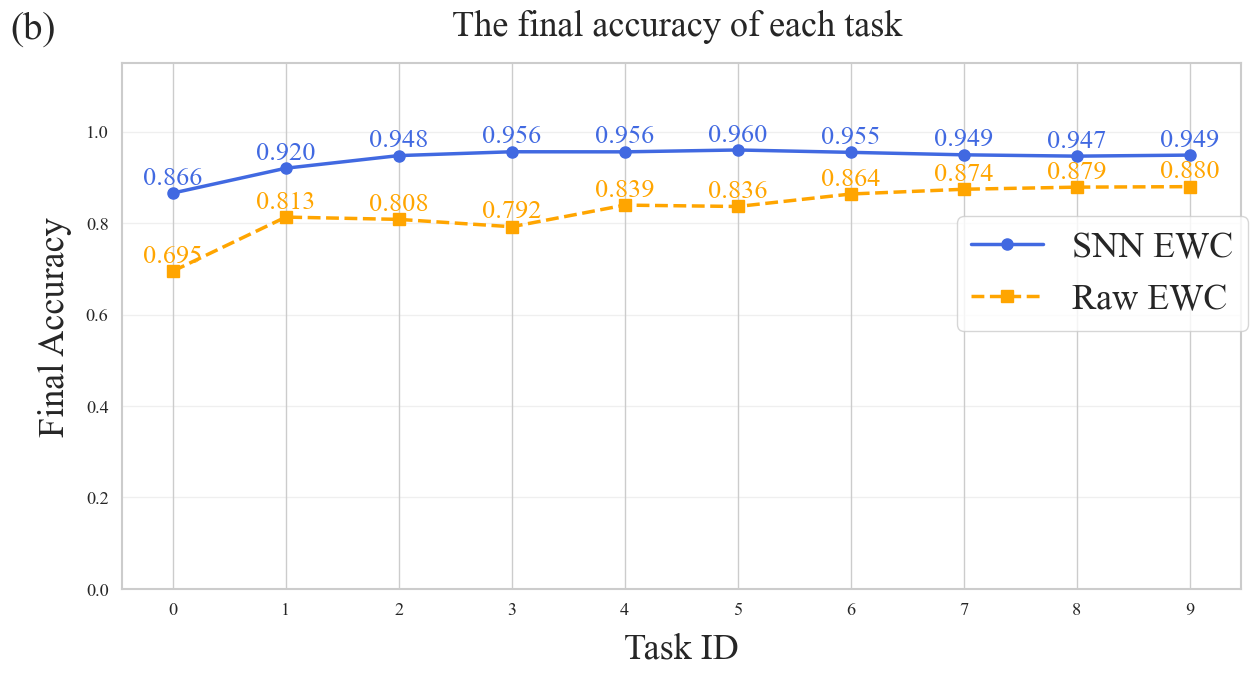

In [94]:
import numpy as np
import matplotlib.pyplot as plt

def compare_final_accuracies_lineplot(ewc_final_acc, raw_ewc_final_acc):
    """
    用折线图比较EWC和raw_EWC的最终任务精度
    
    参数:
        ewc_final_acc: ewc_process返回的final_acc字典
        raw_ewc_final_acc: raw_ewc返回的final_acc字典
    """
    plt.figure(figsize=(13,7))
    sns.set(style="whitegrid", font_scale=1.2)
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.linewidth'] = 1.5

    # 获取任务列表并排序
    tasks = sorted(ewc_final_acc.keys())
    x = np.arange(len(tasks))
    
    # 准备数据
    ewc_acc = [ewc_final_acc[task] for task in tasks]
    raw_acc = [raw_ewc_final_acc.get(task, 0) for task in tasks]
    
    # 绘制折线图（带标记点）
    plt.plot(tasks, ewc_acc, marker='o', markersize=8, label='SNN EWC', 
             color='royalblue', linewidth=2.5, linestyle='-')
    plt.plot(tasks, raw_acc, marker='s', markersize=8, label='Raw EWC', 
             color='orange', linewidth=2.5, linestyle='--')
    
    # 添加数值标签
    for i, (ewc, raw) in enumerate(zip(ewc_acc, raw_acc)):
        plt.text(i, ewc + 0.02, f'{ewc:.3f}', ha='center', color='royalblue', fontsize=19)
        plt.text(i, raw + 0.02, f'{raw:.3f}', ha='center', color='orange', fontsize=19)
    
    # 图表装饰
    plt.xlabel('Task ID',labelpad=10, fontsize=26)
    plt.ylabel('Final Accuracy',labelpad=10, fontsize=26)
    plt.title('The final accuracy of each task ', fontsize=26, pad=20)
    plt.xticks(tasks)
    plt.ylim(0, 1.15)

    # 添加辅助网格线和图例
    plt.grid(True, axis='y', alpha=0.3)
    plt.legend(loc='center left',
           bbox_to_anchor=(0.73, 0.60), fontsize=26)
    plt.text(-0.1, 1.1, '(b)', transform=plt.gca().transAxes, 
            fontsize=28, va='top', ha='left')
    # 美化布局
    plt.tight_layout()
    plt.savefig("pmnist2.pdf", format='pdf', bbox_inches='tight', dpi=450)
    plt.savefig("pmnist2.svg", format='svg', bbox_inches='tight', dpi=450)
    plt.savefig("pmnist2.png", format='png', bbox_inches='tight', dpi=450)
    plt.show()

# 使用示例（保持和之前相同的调用方式）
compare_final_accuracies_lineplot(final_ewc, final_raw)

In [35]:
# loss_plot(loss_ewc)

In [36]:
# accuracy_plot(acc_ewc)

In [37]:
# plt.plot(acc[0], label="adam")
# plt.plot(acc_ewc[0], label="ewc")
# plt.legend()

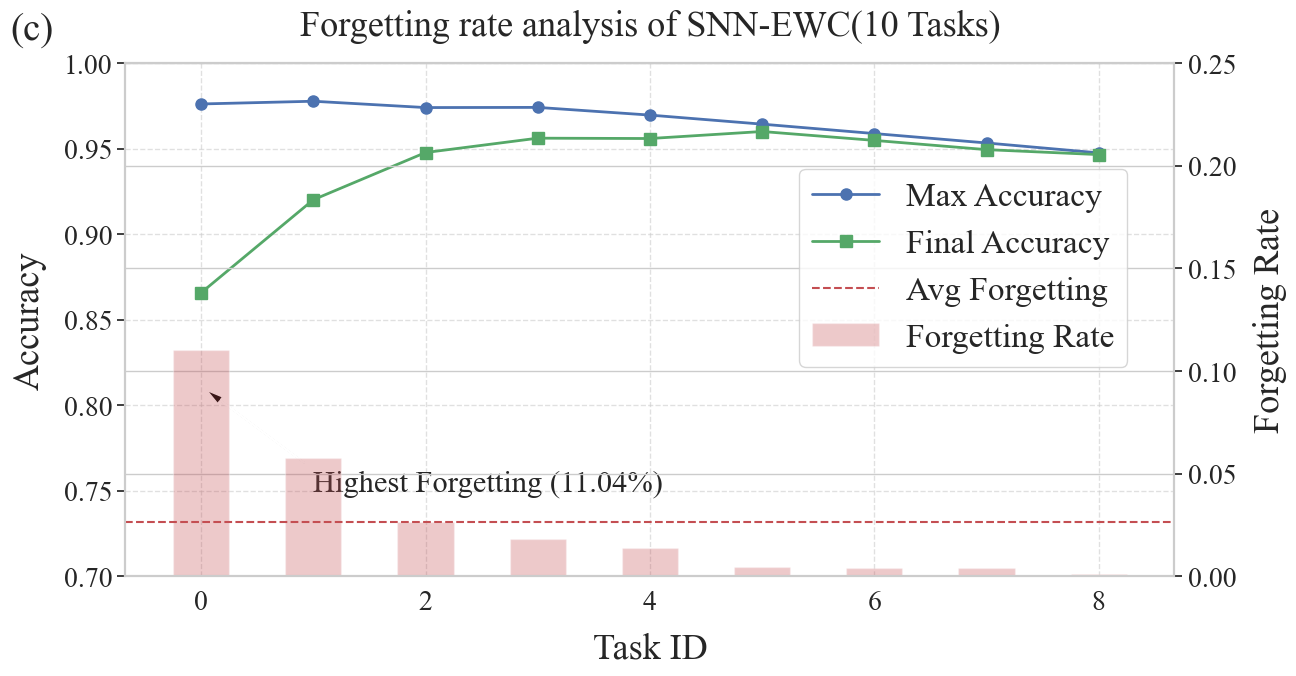

In [95]:
# import matplotlib.pyplot as plt
# import numpy as np

# tasks = np.arange(9)
# max_acc = [0.9764, 0.9781, 0.9766, 0.9717, 0.9661, 0.9678, 0.9629, 0.9564, 0.9521]
# final_acc = [0.8111, 0.9156, 0.9562, 0.9572, 0.9545, 0.9575, 0.9580, 0.9516, 0.9515]
# forgetting = [0.1653, 0.0625, 0.0204, 0.0145, 0.0116, 0.0103, 0.0049, 0.0048, 0.0006]
# fig, ax1 = plt.subplots(figsize=(12, 6))

# # 绘制准确率曲线
# ax1.plot(tasks, max_acc, 'b-o', label='Max Accuracy', linewidth=2)
# ax1.plot(tasks, final_acc, 'g-s', label='Final Accuracy', linewidth=2)
# ax1.set_xlabel('Task ID', fontsize=14)
# ax1.set_ylabel('Accuracy', fontsize=14)
# ax1.set_ylim(0.7, 1.0)
# ax1.grid(linestyle='--', alpha=0.6)

# # 绘制遗忘率柱状图
# ax2 = ax1.twinx()
# ax2.bar(tasks, forgetting, color='r', alpha=0.4, label='Forgetting Rate')
# ax2.axhline(0.0328, color='r', linestyle='--', label='Avg Forgetting')
# ax2.set_ylabel('Forgetting Rate', fontsize=12)
# ax2.set_ylim(0, 0.25)

# # 标注关键点
# ax1.annotate('Highest Forgetting (16.53%)', xy=(0, 0.7715), xytext=(1, 0.65),
#              arrowprops=dict(facecolor='black', shrink=0.05))

# fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
# plt.title('Forgetting rate analysis of SNN-EWC(10 Tasks)', fontsize=18)
# plt.show()
import matplotlib.pyplot as plt
import numpy as np
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize'] = 20  # x 轴刻度字体大小
plt.rcParams['ytick.labelsize'] = 20  # y 轴刻度字体大小
tasks = np.arange(9)
# max_acc = [0.9764, 0.9781, 0.9766, 0.9717, 0.9661, 0.9678, 0.9629, 0.9564, 0.9521]
# final_acc = [0.8111, 0.9156, 0.9562, 0.9572, 0.9545, 0.9575, 0.9580, 0.9516, 0.9515]
# forgetting = [0.1653, 0.0625, 0.0204, 0.0145, 0.0116, 0.0103, 0.0049, 0.0048, 0.0006]
max_acc = [0.9761, 0.9777, 0.9740, 0.9741, 0.9696, 0.9643, 0.9588, 0.9533, 0.9475]
final_acc = [0.8657, 0.9201, 0.9477, 0.9561, 0.9559, 0.9600, 0.9548, 0.9494, 0.9465]
forgetting = [0.1104, 0.0576, 0.0263, 0.0180, 0.0137, 0.0043, 0.0040, 0.0039, 0.0010]
fig, ax1 = plt.subplots(figsize=(14, 7))

# 绘制准确率曲线
ax1.plot(tasks, max_acc, 'b-o', label='Max Accuracy', linewidth=2, markersize=8)
ax1.plot(tasks, final_acc, 'g-s', label='Final Accuracy', linewidth=2, markersize=8)
ax1.set_xlabel('Task ID',labelpad=12, fontsize=26)
ax1.set_ylabel('Accuracy',labelpad=12, fontsize=26)
ax1.set_ylim(0.7, 1.0)
ax1.grid(linestyle='--', alpha=0.6)

# 绘制遗忘率柱状图
ax2 = ax1.twinx()
bars = ax2.bar(tasks, forgetting, color='r', alpha=0.3, label='Forgetting Rate', width=0.5)
ax2.axhline(0.0266, color='r', linestyle='--', linewidth=1.5, label='Avg Forgetting')
ax2.set_ylabel('Forgetting Rate',labelpad=12, fontsize=26)
ax2.set_ylim(0, 0.25)

# 标注关键点
ax1.annotate('Highest Forgetting (11.04%)', xy=(0, 0.8111), xytext=(1, 0.75),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),fontsize = 22)

# 智能定位图例（自动寻找空白区域）
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

fig.legend(lines1 + lines2, labels1 + labels2,
           loc='center left',
           bbox_to_anchor=(0.57, 0.60),
           ncol=1,
           fontsize=24)
plt.text(-0.11, 1.1, '(c)', transform=ax1.transAxes, 
         fontsize=28, va='top', ha='left')
plt.title('Forgetting rate analysis of SNN-EWC(10 Tasks)', fontsize=26, pad=20)
plt.tight_layout()

plt.subplots_adjust(right=0.85)  # 为右侧y轴留出空间
plt.savefig("pmnist3.pdf", format='pdf', bbox_inches='tight', dpi=450)
plt.savefig("pmnist3.svg", format='svg', bbox_inches='tight', dpi=450)
plt.savefig("pmnist3.png", format='png', bbox_inches='tight', dpi=450)
plt.show()

In [100]:
import pymupdf  # 处理 PDF
import os
from PIL import Image  # 处理 PNG
import io
import pycairo  # 处理 SVG

def concatenate_images(input_files, output_pdf, output_png=None, output_svg=None, gap=20, dpi=450):
    """
    将多张PDF竖向拼接，生成PDF、PNG和SVG格式
    :param input_files: 输入的PDF文件列表（按顺序拼接）
    :param output_pdf: 输出的PDF路径（必选）
    :param output_png: 输出的PNG路径（可选）
    :param output_svg: 输出的SVG路径（可选）
    :param gap: 图片间隙（单位：点，默认20）
    :param dpi: 图像分辨率（默认450）
    """
    # 1. 检查输入
    if len(input_files) != 3:
        raise ValueError("需要3个PDF文件")

    # 2. 获取所有PDF的尺寸和图像数据
    docs = []
    pixmaps = []
    widths = []
    heights = []

    for pdf in input_files:
        doc = pymupdf.open(pdf)
        page = doc[0]
        pix = page.get_pixmap(dpi=dpi)  # 450 DPI 渲染
        docs.append(doc)
        pixmaps.append(pix)
        widths.append(pix.width)
        heights.append(pix.height)

    # 3. 计算总尺寸（含间隙）
    gap_pixels = int(gap * dpi / 72)  # 将点转换为像素
    total_height = sum(heights) + gap_pixels * (len(input_files) - 1)
    max_width = max(widths)

    # 4. 生成 PDF
    pdf_doc = pymupdf.open()
    pdf_page = pdf_doc.new_page(width=max_width, height=total_height)
    y_pdf = 0
    for i in range(len(input_files)):
        pdf_page.insert_image(
            pymupdf.Rect(0, y_pdf, widths[i], y_pdf + heights[i]),
            pixmap=pixmaps[i]
        )
        y_pdf += heights[i] + gap
    pdf_doc.save(output_pdf)
    print(f"✅ PDF 已生成: {os.path.abspath(output_pdf)}")

    # 5. 生成 PNG（如果指定了输出路径）
    if output_png:
        png_image = Image.new("RGB", (max_width, total_height), (255, 255, 255))
        y_png = 0
        for i in range(len(input_files)):
            img = Image.open(io.BytesIO(pixmaps[i].tobytes()))
            png_image.paste(img, (0, y_png))
            y_png += heights[i] + gap_pixels
        png_image.save(output_png, dpi=(dpi, dpi))
        print(f"✅ PNG 已生成: {os.path.abspath(output_png)} (450 DPI)")

    # 6. 生成 SVG（如果指定了输出路径）
    if output_svg:
        svg_surface = cairo.SVGSurface(output_svg, max_width, total_height)
        svg_ctx = cairo.Context(svg_surface)
        y_svg = 0
        for i in range(len(input_files)):
            # 将 PDF 页面转换为 PNG 并嵌入 SVG
            img_data = io.BytesIO(pixmaps[i].tobytes())
            img_surface = cairo.ImageSurface.create_from_png(img_data)
            svg_ctx.set_source_surface(img_surface, 0, y_svg)
            svg_ctx.paint()
            y_svg += heights[i] + gap_pixels
        svg_surface.finish()
        print(f"✅ SVG 已生成: {os.path.abspath(output_svg)}")

    # 7. 关闭所有文档
    for doc in docs:
        doc.close()

# 使用示例
if __name__ == "__main__":
    # 输入文件（替换为你的PDF）
    pdf_files = ["pmnist.pdf", "pmnist2.pdf", "pmnist3.pdf"]
    
    # 输出文件
    output_pdf = "combined.pdf"  # PDF（必选）
    output_png = "combined.png"  # PNG（可选）
    output_svg = "combined.svg"  # SVG（可选）
    
    # 执行拼接（间隙30点，450 DPI）
    concatenate_images(
        input_files=pdf_files,
        output_pdf=output_pdf,
        output_png=output_png,
        output_svg=output_svg,
        gap=30,
        dpi=450
    )

ModuleNotFoundError: No module named 'pycairo'

In [101]:
import pymupdf
import os
from PIL import Image  # 用于处理PNG图像

def vertical_concatenate_pdfs(input_files, output_pdf, output_png=None, gap=20, dpi=450):
    """
    将多张PDF竖向拼接，同时生成PDF和PNG格式
    :param input_files: 输入PDF文件列表(按从上到下顺序)
    :param output_pdf: 输出的PDF文件路径
    :param output_png: 输出的PNG文件路径(可选)
    :param gap: 图片之间的间隙大小（单位：点，默认20）
    :param dpi: PNG输出的分辨率（默认300）
    """
    # 1. 检查文件
    if len(input_files) != 3:
        raise ValueError("需要3个PDF文件")
    
    # 2. 获取每页尺寸和图像数据
    docs = []
    pixmaps = []
    widths = []
    heights = []
    
    for pdf in input_files:
        doc = pymupdf.open(pdf)
        page = doc[0]
        pix = page.get_pixmap(dpi=dpi)
        docs.append(doc)
        pixmaps.append(pix)
        widths.append(pix.width)
        heights.append(pix.height)
    
    # 3. 计算总尺寸（增加间隙高度）
    gap_pixels = int(gap * dpi / 72)  # 将点转换为像素
    total_height = sum(heights) + gap_pixels * (len(input_files) - 1)
    max_width = max(widths)
    
    # 4. 创建PDF
    pdf_doc = pymupdf.open()
    pdf_page = pdf_doc.new_page(width=max_width, 
                              height=sum(heights) + gap * (len(input_files) - 1))
    
    # 5. 创建PNG画布
    if output_png:
        png_image = Image.new("RGB", (max_width, total_height), (255, 255, 255))
    
    # 6. 拼接图片
    y_offset_pdf = 0  # PDF的Y坐标（以点为单位）
    y_offset_png = 0  # PNG的Y坐标（以像素为单位）
    
    for i in range(len(input_files)):
        # PDF拼接
        rect = pymupdf.Rect(0, y_offset_pdf, 
                           widths[i], 
                           y_offset_pdf + heights[i])
        pdf_page.insert_image(rect, pixmap=pixmaps[i])
        y_offset_pdf += heights[i] + gap
        
        # PNG拼接
        if output_png:
            img = Image.open(io.BytesIO(pixmaps[i].tobytes()))
            png_image.paste(img, (0, y_offset_png))
            y_offset_png += heights[i] + gap_pixels
        
        docs[i].close()
    
    # 7. 保存PDF
    pdf_doc.save(output_pdf)
    print(f"✅ PDF拼接完成！保存至: {os.path.abspath(output_pdf)}")
    
    # 8. 保存PNG
    if output_png:
        png_image.save(output_png, dpi=(dpi, dpi))
        print(f"✅ PNG拼接完成！保存至: {os.path.abspath(output_png)}")
        print(f"PNG分辨率: {dpi} DPI, 尺寸: {max_width}x{total_height} 像素")

# 使用示例
if __name__ == "__main__":
    import io
    
    # 输入输出设置
    pdf_files = ["pmnist.pdf", "pmnist2.pdf", "pmnist3.pdf"]  # 替换为你的文件
    output_pdf = "combined.pdf"
    output_png = "combined.png"  # 设为None则不生成PNG
    
    # 执行拼接（间隙30点，PNG分辨率300DPI）
    vertical_concatenate_pdfs(
        input_files=pdf_files,
        output_pdf=output_pdf,
        output_png=output_png,
        gap=30,
        dpi=300
    )

✅ PDF拼接完成！保存至: /home/lipuyang/lab1/combined.pdf
✅ PNG拼接完成！保存至: /home/lipuyang/lab1/combined.png
PNG分辨率: 300 DPI, 尺寸: 3911x6618 像素


In [104]:
# 保存函数
def save_ewc_data(loss, acc, final, filename='ewc_data.pkl'):
    import pickle
    with open(filename, 'wb') as f:
        pickle.dump({'loss_ewc': loss, 'acc_ewc': acc, 'final_ewc': final}, f)

# 加载函数
def load_ewc_data(filename='ewc_data.pkl'):
    import pickle
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    return data['loss_ewc'], data['acc_ewc'], data['final_ewc']

# 使用示例
save_ewc_data(loss_ewc, acc_ewc, final_ewc)
loaded_loss, loaded_acc, loaded_final = load_ewc_data()


In [105]:
import numpy as np

# 假设原始数据是 NumPy 数组
assert np.array_equal(loss_ewc, loaded_loss), "loss_ewc 数据不一致！"
assert np.array_equal(acc_ewc, loaded_acc), "acc_ewc 数据不一致！"
assert np.array_equal(final_ewc, loaded_final), "final_ewc 数据不一致！"

print("✅ 数据验证通过，保存和加载的数据一致！")

✅ 数据验证通过，保存和加载的数据一致！


In [ ]:
# # from bayes_opt import BayesianOptimization
# # num_tasks=10

# # def optimize_lambda():
# #     # 定义目标函数
# #     def objective_function(lambda_val):
# #         lambda_val = int(lambda_val)
# #         print(f"\nTesting λ = {lambda_val}")

# #         # 运行简化的EWC流程（例如仅训练前3个任务，5个epoch）
# #         _, acc_ewc = ewc_process(
# #             epochs=10, 
# #             base_importance=lambda_val,
# #               # 需确保代码支持动态调整任务数量
# #         )

# #         # 计算平均准确率
# #         avg_acc = sum([acc_ewc[task][-1] for task in range(3)]) / 3
# #         return avg_acc

# #     # 设置参数范围
# #     pbounds = {'lambda_val': (1000, 20000)}

# #     # 初始化贝叶斯优化器
# #     optimizer = BayesianOptimization(
# #         f=objective_function,
# #         pbounds=pbounds,
# #         random_state=42,
# #     )

# #     # 运行优化
# #     optimizer.maximize(init_points=4, n_iter=16)

# #     # 输出结果
# #     best_lambda = optimizer.max['params']['lambda_val']
# #     print(f"\nOptimal initial λ: {best_lambda:.0f}")

# #     return best_lambda

# # # 执行优化并获取最佳λ
# # best_lambda = optimize_lambda()

# # # 使用最佳λ运行完整训练
# # final_loss, final_acc = ewc_process(
# #     epochs=10, 
# #     base_importance=best_lambda,
# #     # 完整任务数量
# # )


# from bayes_opt import BayesianOptimization
# import sys

# num_tasks =10

# def optimize_lambda():
#     # 定义目标函数
#     def objective_function(lambda_val):
#         lambda_val = int(lambda_val)
#         print(f"\nTesting λ = {lambda_val}")

#         # 运行简化的EWC流程（例如仅训练前3个任务，5个epoch）
#         _, acc_ewc,final_final_acc = ewc_process(
#             epochs=10, 
#             base_importance=lambda_val,
#             # num_tasks=3  # 仅测试前3个任务进行优化
#         )

#         # 计算平均准确率
#         avg_acc = sum([acc_ewc[task][-1] for task in range(10)]) / 10
#         return avg_acc

#     # 设置参数范围
#     pbounds = {'lambda_val': (1000, 100000)}

#     # 初始化贝叶斯优化器
#     optimizer = BayesianOptimization(
#         f=objective_function,
#         pbounds=pbounds,
#         random_state=42,
#     )

#     # 运行优化
#     optimizer.maximize(init_points=6, n_iter=24)

#     # 输出结果
#     best_lambda = optimizer.max['params']['lambda_val']
#     print(f"\nOptimal initial λ: {best_lambda:.0f}")

#     return best_lambda

# # 将所有输出重定向到文件（使用UTF-8编码）
# original_stdout = sys.stdout
# with open('training_log.txt', 'w', encoding='utf-8') as f:  # 添加encoding='utf-8'
#     sys.stdout = f  # 重定向所有print输出到文件
    
#     try:
#         # 执行优化并获取最佳λ
#         print("Starting Bayesian optimization for lambda...")
#         best_lambda = optimize_lambda()
        
#         # 使用最佳λ运行完整训练
#         print("\nStarting full training with optimal lambda...")
#         final_loss, final_acc,final = ewc_process(
#             epochs=10, 
#             base_importance=int(best_lambda),
#             # num_tasks=num_tasks
#         )
        
#         # 打印最终结果
#         print(f"\nFinal training results - Loss: {final_loss}, Accuracy: {final_acc}")
        
#     except Exception as e:
#         print(f"An error occurred: {str(e)}")
#     finally:
#         sys.stdout = original_stdout  # 确保即使出错也能恢复标准输出

# # 可选：在控制台显示最终结果
# print("Optimal lambda saved in training_log.txt")




Task 9: 100%|██████████| 10/10 [01:05<00:00,  6.57s/it]

Optimal lambda saved in training_log.txt
